In [71]:
# Standard library imports
import sys
import os
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import importlib

#%% ======================= PATH SETUP =======================
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')

# Change the working directory to the script directory
os.chdir(current_dir)

# Add utilities directory to Python path
sys.path.insert(0, utilities_dir)

#%% ======================= FUNCTION IMPORTS =======================
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement
from bem_solution_functions import (
    Circle_n, solveExteriorBoundary, solveExterior, generateInteriorPoints_excluding_circle
)

import plotting_functions

importlib.reload(plotting_functions)

from plotting_functions import plot_bem_displacements_errors

In [2]:
#%% ======================= PROBLEM SETUP =======================
k = 3.0                # Wave number
n = 15                 # Boundary elements
n_dom = 2 * 40         # Domain sampling points per axis
r_exclude = np.pi / 4  # Obstacle radius
l_se = np.pi           # Half-length of computational domain
n_grid = 501           # Grid points

#%% ======================= BOUNDARY MESH =======================
aVertex, aElement = Circle_n(n=n, radius=r_exclude)
num_elements = aElement.shape[0]
aCenters = 0.5 * (aVertex[aElement[:, 0]] + aVertex[aElement[:, 1]])
theta = np.arctan2(aCenters[:, 1], aCenters[:, 0])  # Normal angle

#%% ======================= BOUNDARY CONDITIONS =======================
alpha = np.full(num_elements, 0.0, dtype=complex)
beta = np.full(num_elements, 1.0, dtype=complex)
f = np.empty(num_elements, dtype=complex)
phi = np.full(num_elements, 0.0, dtype=complex)
v = np.full(num_elements, 0.0, dtype=complex)

# Incident field + derivative
kx = k * aCenters[:, 0]
phi_inc = np.exp(1j * kx)
f = -1j * k * np.cos(theta) * phi_inc

#%% ======================= INTERIOR POINTS =======================
points_outside, points_inside = generateInteriorPoints_excluding_circle(
    Nx=n_dom, Ny=n_dom,
    xmin=-2 * l_se, xmax=2 * l_se,
    ymin=-2 * l_se, ymax=2 * l_se,
    r_exclude=r_exclude
)
interiorIncidentPhi = np.zeros(points_outside.shape[0], dtype=complex)

#%% ======================= SOLVE EXTERIOR BEM =======================
c, density = None, None
v, phi = solveExteriorBoundary(
    k, alpha, beta, f, phi, v,
    aVertex, aElement,
    c, density,
    'exterior'
)

#%% ======================= EVALUATE FIELD =======================
interiorPhi = solveExterior(
    k, v, phi,
    interiorIncidentPhi,
    points_outside,
    aVertex, aElement,
    'exterior'
)

#%% ======================= INTERPOLATION TO GRID =======================
Y, X = np.mgrid[-2*l_se:2*l_se:n_grid*1j, -2*l_se:2*l_se:n_grid*1j]
grid_z = griddata(points_outside, interiorPhi, (X, Y), method='cubic')
grid_z = np.ma.masked_where(np.sqrt(X**2 + Y**2) < r_exclude, grid_z)

u_scn_amp = grid_z.real   # amplitude
u_scn_phase = grid_z.imag # phase

#%% ======================= ANALYTICAL SOLUTION =======================
R_exact = np.sqrt(X**2 + Y**2)
u_inc_exact, u_scn_exact, u_exact = sound_hard_circle_calc(k, r_exclude, X, Y, n_terms=None)

# Mask solutions
u_inc_exact = mask_displacement(R_exact, r_exclude, l_se, u_inc_exact)
u_scn_exact = mask_displacement(R_exact, r_exclude, l_se, u_scn_exact)
u_exact = mask_displacement(R_exact, r_exclude, l_se, u_exact)

#%% ======================= ERROR COMPUTATION =======================
R_grid = np.sqrt(X**2 + Y**2)
u_scn_exact_masked = np.copy(u_scn_exact)
u_scn_amp_masked = np.copy(u_scn_amp)
u_scn_exact_masked[R_grid < r_exclude] = 0
u_scn_amp_masked[R_grid < r_exclude] = 0

relative_error = np.linalg.norm(
    u_scn_exact_masked.real - u_scn_amp_masked.real, 2
) / np.linalg.norm(u_scn_exact_masked.real, 2)

# Ensure folder exists
# error_folder = os.path.join(os.path.dirname(__file__), "data")
# os.makedirs(error_folder, exist_ok=True)

# error_file = os.path.join(error_folder, f"bem_relative_error_{date_str}.txt")
# error_file_no_date = os.path.join(error_folder, "bem_relative_error.txt")

# with open(error_file, "w") as f:
#     f.write(f"Relative L2 error: {relative_error:.6e}\n")

# with open(error_file_no_date, "w") as f:
#     f.write(f"Relative L2 error: {relative_error:.6e}\n")

# print(f"Relative L2 error: {relative_error:.2e}")


In [3]:
# Línea radial desde el centro hacia +x, con y=0
x_line = np.linspace(np.pi, 10 * np.pi, 500)
y_line = np.zeros_like(x_line)
points_line = np.vstack((x_line, y_line)).T

# Evaluar campo BEM en puntos de la línea
interiorIncidentPhi_line = np.zeros(points_line.shape[0], dtype=complex)
phi_bem_line = solveExterior(
    k, v, phi,
    interiorIncidentPhi_line,
    points_line,
    aVertex, aElement,
    'exterior'
)

# Solución exacta
X_line, Y_line = x_line, y_line
u_inc_line, u_scn_exact_line, u_tot_exact_line = sound_hard_circle_calc(
    k, r_exclude,
    X_line, Y_line
)

# Error relativo
error_line = np.abs(np.real(u_scn_exact_line) - np.real(phi_bem_line))
rel_error_line = error_line / np.max(np.real(u_scn_exact_line))

 
#%% ======================= PROBLEM SETUP (10π DOMAIN) =======================

k = 3.0                     # Wave number
n = 15                      # Boundary elements
n_dom_10 = 2 * 40          # Increased sampling for larger domain
r_exclude = np.pi / 4       # Obstacle radius
l_10 = 10 * np.pi           # Half-length of domain (10π)
n_grid_10 = 501             # Grid points

#%% ======================= BOUNDARY MESH =======================

aVertex, aElement = Circle_n(n=n, radius=r_exclude)
num_elements = aElement.shape[0]
aCenters = 0.5 * (aVertex[aElement[:, 0]] + aVertex[aElement[:, 1]])
theta = np.arctan2(aCenters[:, 1], aCenters[:, 0])

#%% ======================= BOUNDARY CONDITIONS =======================

alpha = np.full(num_elements, 0.0, dtype=complex)
beta = np.full(num_elements, 1.0, dtype=complex)
f = np.empty(num_elements, dtype=complex)
phi = np.full(num_elements, 0.0, dtype=complex)
v = np.full(num_elements, 0.0, dtype=complex)

kx = k * aCenters[:, 0]
phi_inc = np.exp(1j * kx)
f = -1j * k * np.cos(theta) * phi_inc

#%% ======================= INTERIOR POINTS =======================

points_outside_10, points_inside_10 = generateInteriorPoints_excluding_circle(
    Nx=n_dom_10, Ny=n_dom_10,
    xmin=-l_10, xmax=l_10,
    ymin=-l_10, ymax=l_10,
    r_exclude=r_exclude
)

interiorIncidentPhi_10 = np.zeros(points_outside_10.shape[0], dtype=complex)

#%% ======================= SOLVE EXTERIOR BEM =======================

c, density = None, None
v, phi = solveExteriorBoundary(
    k, alpha, beta, f, phi, v,
    aVertex, aElement,
    c, density,
    'exterior'
)

#%% ======================= EVALUATE FIELD =======================

interiorPhi_10 = solveExterior(
    k, v, phi,
    interiorIncidentPhi_10,
    points_outside_10,
    aVertex, aElement,
    'exterior'
)

#%% ======================= INTERPOLATION TO GRID =======================

Y_10, X_10 = np.mgrid[
    -l_10:l_10:n_grid_10*1j,
    -l_10:l_10:n_grid_10*1j
]

grid_z_10 = griddata(points_outside_10, interiorPhi_10, (X_10, Y_10), method='cubic')
grid_z_10 = np.ma.masked_where(np.sqrt(X_10**2 + Y_10**2) < r_exclude, grid_z_10)

u_scn_amp_10 = grid_z_10.real
u_scn_phase_10 = grid_z_10.imag
print(f"Interpolated BEM field on 10π domain with shape: {grid_z_10.shape}")
#%% ======================= ANALYTICAL SOLUTION =======================

R_10 = np.sqrt(X_10**2 + Y_10**2)

u_inc_exact_10, u_scn_exact_10, u_exact_10 = sound_hard_circle_calc(
    k, r_exclude, X_10, Y_10, n_terms=None
)

u_inc_exact_10 = mask_displacement(R_10, r_exclude, l_10, u_inc_exact_10)
u_scn_exact_10 = mask_displacement(R_10, r_exclude, l_10, u_scn_exact_10)
u_exact_10 = mask_displacement(R_10, r_exclude, l_10, u_exact_10)
print(f"Computed analytical solution on 10π domain with shape: {u_scn_exact_10.shape}")

#%% ======================= ERROR FIELD =======================

error_field = np.abs(np.real(u_scn_exact_10) - u_scn_amp_10)

# Levels: 1π → 10π
n_levels = np.arange(1, 11)

error_map = np.zeros_like(error_field)
prev_bound = 0.0
avg_errors = []

for n_level in n_levels:
    current_bound = n_level * np.pi

    mask_outer = (np.abs(X_10) <= current_bound) & (np.abs(Y_10) <= current_bound)
    mask_inner = (np.abs(X_10) <= prev_bound) & (np.abs(Y_10) <= prev_bound)

    ring_mask = mask_outer & (~mask_inner)
    #print(f"Points in ring {n_level}: {np.sum(ring_mask)}")
    if np.any(ring_mask):
        values = error_field[ring_mask]

        if np.any(~np.isnan(values)):
            avg_error = np.nanmean(values)
        else:
            avg_error = np.nan
        avg_errors.append(avg_error)
        #print(f"n={n_level}, Avg Error: {avg_error:.2e}")
        error_map[ring_mask] = avg_error

        #print(f"n={n_level}, L={current_bound:.2f}, Avg Error: {avg_error:.2e}")

    prev_bound = current_bound

# Normalize (optional)
error_map = error_map / np.max(np.abs(np.real(u_scn_exact_10)))
 

Interpolated BEM field on 10π domain with shape: (501, 501)
Computed analytical solution on 10π domain with shape: (501, 501)


/home/orincon/benchmarking-bem-pinns/main/04_generalization/../../utilities/plotting_functions.py:672: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


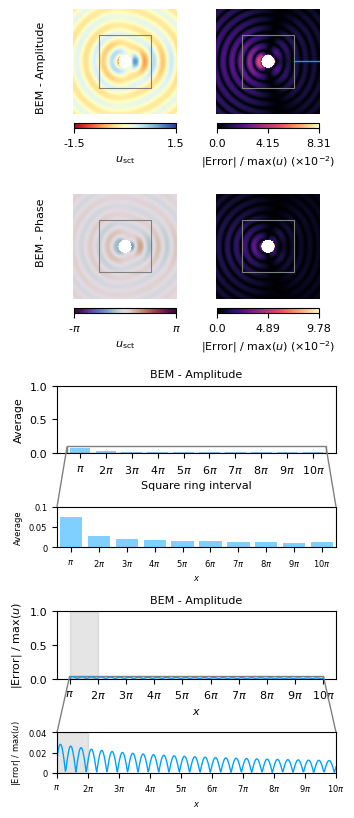

In [72]:
plot_bem_displacements_errors(
    X, Y,
    u_scn_amp,
    np.real(u_inc_exact) + u_scn_amp,
    np.abs(np.real(u_scn_exact) - u_scn_amp),
    u_scn_phase,
    u_scn_phase + np.real(u_inc_exact),
    np.abs(np.imag(u_scn_exact) - u_scn_phase),
    x_line,
    rel_error_line,
    avg_errors
)